In [1]:
#import pandas for data analysis
import pandas as pd

#read  the dataset
df = pd.read_csv(
    "../data/KDDTrain+.txt",
    header=None
)
#display the head rows
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
#check rows and columns
print(df.shape)

(125973, 43)


In [3]:
#view data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  str    
 2   2       125973 non-null  str    
 3   3       125973 non-null  str    
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      125973 non-nu

In [4]:
df[41].value_counts()

41
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [5]:
column_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "attack_type",
    "difficulty_level"
]

df.columns = column_names

In [6]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [7]:
df[['protocol_type','service','attack_type']].head(10)

,protocol_type,service,attack_type
0,tcp,ftp_data,normal
1,udp,other,normal
2,tcp,private,neptune
3,tcp,http,normal
4,tcp,http,normal
5,tcp,private,neptune
6,tcp,private,neptune
7,tcp,private,neptune
8,tcp,remote_job,neptune
9,tcp,private,neptune


In [8]:
#explore data
df['attack_type'].nunique()

23

In [9]:
df['protocol_type'].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [10]:
df['service'].value_counts().head(10)

service
http        40338
private     21853
domain_u     9043
smtp         7313
ftp_data     6860
eco_i        4586
other        4359
ecr_i        3077
telnet       2353
finger       1767
Name: count, dtype: int64

In [11]:
# Display all unique attack types present in the dataset
print(df["attack_type"].unique())

<ArrowStringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str


In [12]:
# Create a dictionary to map attack names to attack categories

attack_mapping = {

    # Normal Traffic
    "normal": "Normal",

    # DoS Attacks
    "neptune": "DoS",
    "smurf": "DoS",
    "back": "DoS",
    "teardrop": "DoS",
    "pod": "DoS",
    "land": "DoS",

    # Probe Attacks
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",

    # Unauthorized Access Attacks
    "guess_passwd": "Unauthorized Access",
    "ftp_write": "Unauthorized Access",
    "imap": "Unauthorized Access",
    "warezclient": "Unauthorized Access",
    "warezmaster": "Unauthorized Access",
    "multihop": "Unauthorized Access",
    "phf": "Unauthorized Access",
    "spy": "Unauthorized Access",

    # Privilege Escalation Attacks
    "buffer_overflow": "Privilege Escalation",
    "rootkit": "Privilege Escalation",
    "loadmodule": "Privilege Escalation",
    "perl": "Privilege Escalation"
}

# Create a new column called attack_category
# using the attack_type column

df["attack_category"] = df["attack_type"].map(attack_mapping)

In [13]:
# Display attack type and category side by side

df[["attack_type", "attack_category"]].head(20)

,attack_type,attack_category
0,normal,Normal
1,normal,Normal
2,neptune,DoS
3,normal,Normal
4,normal,Normal
5,neptune,DoS
6,neptune,DoS
7,neptune,DoS
8,neptune,DoS
9,neptune,DoS


In [14]:
#Count how many records belong to each category

df["attack_category"].value_counts()

attack_category
Normal                  67343
DoS                     45927
Probe                   11656
Unauthorized Access       995
Privilege Escalation       52
Name: count, dtype: int64

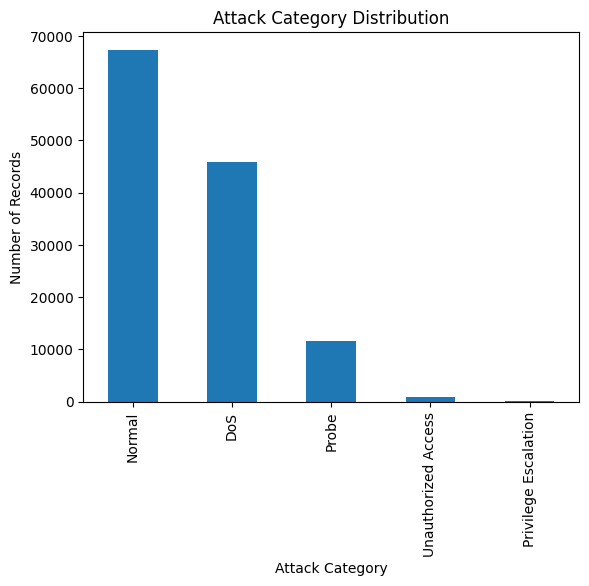

In [15]:
#Import plotting library
import matplotlib.pyplot as plt

# Count records in each attack category
attack_counts = df["attack_category"].value_counts()

# Create a bar chart
attack_counts.plot(kind="bar")

# Chart title
plt.title("Attack Category Distribution")

# X-axis label
plt.xlabel("Attack Category")

# Y-axis label
plt.ylabel("Number of Records")

# Display chart
plt.show()

In [16]:
df.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level',
       'attack_category'],
      dtype='str')

In [17]:
#display all column names
for col in df.columns:
    print(col)

duration
protocol_type
service
flag
src_bytes
dst_bytes
land
wrong_fragment
urgent
hot
num_failed_logins
logged_in
num_compromised
root_shell
su_attempted
num_root
num_file_creations
num_shells
num_access_files
num_outbound_cmds
is_host_login
is_guest_login
count
srv_count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
same_srv_rate
diff_srv_rate
srv_diff_host_rate
dst_host_count
dst_host_srv_count
dst_host_same_srv_rate
dst_host_diff_srv_rate
dst_host_same_src_port_rate
dst_host_srv_diff_host_rate
dst_host_serror_rate
dst_host_srv_serror_rate
dst_host_rerror_rate
dst_host_srv_rerror_rate
attack_type
difficulty_level
attack_category


In [18]:
#display important security-related columns
important_cols = [
    "protocol_type",
    "service",
    "src_bytes",
    "dst_bytes",
    "num_failed_logins",
    "logged_in",
    "count",
    "srv_count",
    "attack_type",
    "attack_category"
]

#Show first 15 rows
df[important_cols].head(15)

,protocol_type,service,src_bytes,dst_bytes,num_failed_logins,logged_in,count,srv_count,attack_type,attack_category
0,tcp,ftp_data,491,0,0,0,2,2,normal,Normal
1,udp,other,146,0,0,0,13,1,normal,Normal
2,tcp,private,0,0,0,0,123,6,neptune,DoS
3,tcp,http,232,8153,0,1,5,5,normal,Normal
4,tcp,http,199,420,0,1,30,32,normal,Normal
5,tcp,private,0,0,0,0,121,19,neptune,DoS
6,tcp,private,0,0,0,0,166,9,neptune,DoS
7,tcp,private,0,0,0,0,117,16,neptune,DoS
8,tcp,remote_job,0,0,0,0,270,23,neptune,DoS
9,tcp,private,0,0,0,0,133,8,neptune,DoS


In [19]:
risk_mapping = {
    "Normal": "Low",
    "Probe": "Medium",
    "DoS": "High",
    "Unauthorized Access": "High",
    "Privilege Escalation": "Critical"
}

In [20]:
#Map each attack category to a risk level

risk_mapping = {

    #Normal activity
    "Normal": "Low",

    #Information gathering attacks
    "Probe": "Medium",

    #Service disruption attacks
    "DoS": "High",

    #Unauthorized access attempts
    "Unauthorized Access": "High",

    #Root/Admin compromise
    "Privilege Escalation": "Critical"
}

#Create a new column called risk_level

df["risk_level"] = df["attack_category"].map(risk_mapping)

In [21]:
#Show attack category and assigned risk

df[["attack_type",
    "attack_category",
    "risk_level"]].head(20)

,attack_type,attack_category,risk_level
0,normal,Normal,Low
1,normal,Normal,Low
2,neptune,DoS,High
3,normal,Normal,Low
4,normal,Normal,Low
5,neptune,DoS,High
6,neptune,DoS,High
7,neptune,DoS,High
8,neptune,DoS,High
9,neptune,DoS,High


In [22]:
#Count records by risk level

df["risk_level"].value_counts()

risk_level
Low         67343
High        46922
Medium      11656
Critical       52
Name: count, dtype: int64

In [23]:
# Create recommendations for each attack category

recommendation_mapping = {

    "Normal":
        "No action required. Continue monitoring.",

    "DoS":
        "Investigate source IPs and apply rate limiting or blocking.",

    "Probe":
        "Monitor scanning activity and review exposed services.",

    "Unauthorized Access":
        "Review authentication logs and reset compromised accounts.",

    "Privilege Escalation":
        "Immediately isolate the affected system and perform incident response."
}

#Create a recommendation column

df["recommendation"] = df["attack_category"].map(
    recommendation_mapping
)

In [24]:
# Display our SOC intelligence columns

df[[
    "attack_type",
    "attack_category",
    "risk_level",
    "recommendation"
]].head(15)

,attack_type,attack_category,risk_level,recommendation
0,normal,Normal,Low,No action required. Continue monitoring.
1,normal,Normal,Low,No action required. Continue monitoring.
2,neptune,DoS,High,Investigate source IPs and apply rate limiting...
3,normal,Normal,Low,No action required. Continue monitoring.
4,normal,Normal,Low,No action required. Continue monitoring.
5,neptune,DoS,High,Investigate source IPs and apply rate limiting...
6,neptune,DoS,High,Investigate source IPs and apply rate limiting...
7,neptune,DoS,High,Investigate source IPs and apply rate limiting...
8,neptune,DoS,High,Investigate source IPs and apply rate limiting...
9,neptune,DoS,High,Investigate source IPs and apply rate limiting...


In [25]:
# Save the enriched dataset with our new intelligence columns

df.to_csv(
    "../data/nsl_kdd_enriched.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [26]:
#understanding feature
#first feature investigation
# Count how many records use each protocol

df["protocol_type"].value_counts()

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

In [27]:
# Compare protocol usage across attack categories

pd.crosstab(
    df["protocol_type"],
    df["attack_category"]
)

attack_category,DoS,Normal,Privilege Escalation,Probe,Unauthorized Access
protocol_type,,,,,
icmp,2847,1309,0,4135,0
tcp,42188,53600,49,5857,995
udp,892,12434,3,1664,0


In [28]:
#failed logins feature invetigation:
# Check statistics for failed logins

df["num_failed_logins"].describe()


count    125973.000000
mean          0.001222
std           0.045239
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: num_failed_logins, dtype: float64

In [29]:
# Show records with failed login attempts

df[df["num_failed_logins"] > 0][
    [
        "num_failed_logins",
        "logged_in",
        "attack_type",
        "attack_category"
    ]
].head(20)

,num_failed_logins,logged_in,attack_type,attack_category
405,2,1,normal,Normal
689,1,0,guess_passwd,Unauthorized Access
1792,1,0,normal,Normal
1914,1,0,normal,Normal
2798,1,0,guess_passwd,Unauthorized Access
5001,2,1,normal,Normal
5772,1,0,normal,Normal
5930,1,1,normal,Normal
6636,1,0,guess_passwd,Unauthorized Access
10047,1,0,guess_passwd,Unauthorized Access


In [30]:
#succesful login
# Count successful and unsuccessful logins

df["logged_in"].value_counts()


logged_in
0    76121
1    49852
Name: count, dtype: int64

In [31]:
# Compare login status with attack categories

pd.crosstab(
    df["logged_in"],
    df["attack_category"]
)

attack_category,DoS,Normal,Privilege Escalation,Probe,Unauthorized Access
logged_in,,,,,
0,44970,19486,6,11573,86
1,957,47857,46,83,909


In [32]:
# Compare count statistics by attack category

df.groupby("attack_category")["count"].describe()


,count,mean,std,min,25%,50%,75%,max
attack_category,,,,,,,,
DoS,45927.0,178.090034,104.445748,1.0,109.0,172.0,249.00,511.0
Normal,67343.0,22.517945,54.026086,0.0,1.0,4.0,14.00,511.0
Privilege Escalation,52.0,5.807692,23.454619,1.0,1.0,1.0,1.25,151.0
Probe,11656.0,77.052248,156.470566,0.0,1.0,1.0,30.00,511.0
Unauthorized Access,995.0,1.297487,0.480970,1.0,1.0,1.0,2.00,4.0


In [33]:
#feature relationships # Compare average source bytes by attack category

df.groupby("attack_category")["src_bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
attack_category,,,,,,,,
DoS,45927.0,1176.321162,7.686120e+03,0.0,0.0,0.0,0.0,5.454000e+04
Normal,67343.0,13133.279331,4.181131e+05,0.0,129.0,233.0,324.0,8.958152e+07
Privilege Escalation,52.0,906.230769,1.188260e+03,0.0,4.0,273.0,1567.0,6.274000e+03
Probe,11656.0,385679.838367,1.926641e+07,0.0,0.0,1.0,8.0,1.379964e+09
Unauthorized Access,995.0,307727.300503,1.214966e+06,0.0,334.0,334.0,1224.0,5.135678e+06


In [34]:
# Compare average destination bytes by attack category

df.groupby("attack_category")["dst_bytes"].describe()

,count,mean,std,min,25%,50%,75%,max
attack_category,,,,,,,,
DoS,45927.0,169.201537,1.168004e+03,0.0,0.0,0.0,0.0,8.315000e+03
Normal,67343.0,4329.685223,6.546282e+04,0.0,105.0,379.0,2056.0,7.028652e+06
Privilege Escalation,52.0,5141.961538,1.008151e+04,0.0,1753.0,2907.0,5020.0,7.052900e+04
Probe,11656.0,181074.911805,1.321706e+07,0.0,0.0,0.0,0.0,1.309937e+09
Unauthorized Access,995.0,81822.026131,6.298782e+05,0.0,0.0,0.0,2447.0,5.155468e+06


In [35]:
# Correlation of numeric features with count-like behavior

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("Number of numeric columns:", len(numeric_cols))

numeric_cols

Number of numeric columns: 39


Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
       'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'difficulty_level'],
      dtype='str')

In [36]:
#Compare average values by attack category

important_features = [
    "count",
    "srv_count",
    "logged_in",
    "src_bytes",
    "dst_bytes",
    "num_failed_logins",
    "serror_rate",
    "rerror_rate"
]

df.groupby("attack_category")[important_features].mean().round(2)

,count,srv_count,logged_in,src_bytes,dst_bytes,num_failed_logins,serror_rate,rerror_rate
attack_category,,,,,,,,
DoS,178.09,32.66,0.02,1176.32,169.20,0.00,0.75,0.15
Normal,22.52,27.69,0.71,13133.28,4329.69,0.00,0.01,0.04
Privilege Escalation,5.81,1.27,0.88,906.23,5141.96,0.02,0.04,0.01
Probe,77.05,10.94,0.01,385679.84,181074.91,0.00,0.05,0.44
Unauthorized Access,1.30,2.46,0.91,307727.30,81822.03,0.06,0.01,0.05


In [37]:
#MACHINE LEARNING
#TRAINING MODEL

In [38]:
# Features selected based on our cybersecurity analysis

features = [
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "logged_in",
    "serror_rate",
    "rerror_rate"
]

# X = inputs for the model
X = df[features]

# y = target we want to predict
y = df["attack_category"]

# Check shape
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (125973, 10)
y Shape: (125973,)


In [39]:
#Display data types

X.dtypes

protocol_type        str
service              str
flag                 str
src_bytes          int64
dst_bytes          int64
count              int64
srv_count          int64
logged_in          int64
serror_rate      float64
rerror_rate      float64
dtype: object

In [40]:
#ENCODING : converting into number for computer to understand

In [41]:
# Import Label Encoder

from sklearn.preprocessing import LabelEncoder

In [42]:
#Create encoders

protocol_encoder = LabelEncoder()
service_encoder = LabelEncoder()
flag_encoder = LabelEncoder()

In [43]:
# Convert protocol names into numbers

X["protocol_type"] = protocol_encoder.fit_transform(
    X["protocol_type"]
)

# Convert service names into numbers

X["service"] = service_encoder.fit_transform(
    X["service"]
)

# Convert flag values into numbers

X["flag"] = flag_encoder.fit_transform(
    X["flag"]
)

In [44]:
X.head()

,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,logged_in,serror_rate,rerror_rate
0,1,20,9,491,0,2,2,0,0.0,0.0
1,2,44,9,146,0,13,1,0,0.0,0.0
2,1,49,5,0,0,123,6,0,1.0,0.0
3,1,24,9,232,8153,5,5,1,0.2,0.0
4,1,24,9,199,420,30,32,1,0.0,0.0


In [45]:
# Check if any values are missing

X.isnull().sum()


protocol_type    0
service          0
flag             0
src_bytes        0
dst_bytes        0
count            0
srv_count        0
logged_in        0
serror_rate      0
rerror_rate      0
dtype: int64

In [46]:
#TRAIN -TEST SPLIT

In [47]:
# Import train-test split

from sklearn.model_selection import train_test_split

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures same results every run
)

# Display shapes

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (100778, 10)
Testing Features: (25195, 10)
Training Labels: (100778,)
Testing Labels: (25195,)


In [48]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

# Create model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [49]:
# Predict attack categories

y_pred = rf_model.predict(X_test)

# Show first 10 predictions

print(y_pred[:10])

['Normal' 'DoS' 'DoS' 'DoS' 'Probe' 'Normal' 'DoS' 'DoS' 'DoS' 'Normal']


In [50]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9971819805516967


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

                 DoS       1.00      1.00      1.00      9181
              Normal       1.00      1.00      1.00     13422
Privilege Escalation       0.71      0.45      0.56        11
               Probe       0.99      0.99      0.99      2357
 Unauthorized Access       0.98      0.97      0.98       224

            accuracy                           1.00     25195
           macro avg       0.94      0.88      0.90     25195
        weighted avg       1.00      1.00      1.00     25195



In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 9165     8     0     8     0]
 [    7 13398     2    11     4]
 [    0     6     5     0     0]
 [    8    11     0  2338     0]
 [    0     6     0     0   218]]


In [53]:
#ACCURACY CONCLUSION  :The model performs extremely well for Normal, DoS, Probe,
#and Unauthorized Access categories. 
#However, Privilege Escalation detection remains challenging 
#due to the small number of samples available in the dataset.

In [54]:
#FEATURE IMPORTANCE
# Show feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

         Feature  Importance
3      src_bytes    0.266925
2           flag    0.149477
4      dst_bytes    0.137317
5          count    0.123302
8    serror_rate    0.101809
6      srv_count    0.058881
1        service    0.057695
7      logged_in    0.045644
0  protocol_type    0.033049
9    rerror_rate    0.025901


In [55]:
#MAPPING

In [56]:
# Risk levels for each category

risk_mapping = {
    "Normal": "Low",
    "Probe": "Medium",
    "DoS": "High",
    "Unauthorized Access": "High",
    "Privilege Escalation": "Critical"
}

In [57]:
# SOC recommendations

recommendation_mapping = {
    "Normal":
        "No action required. Continue monitoring.",

    "Probe":
        "Investigate source IP. Review scanning activity and monitor network reconnaissance attempts.",

    "DoS":
        "Investigate source IPs, apply rate limiting, and review firewall logs for flooding behavior.",

    "Unauthorized Access":
        "Review authentication logs and reset potentially compromised accounts.",

    "Privilege Escalation":
        "Immediately investigate affected systems, isolate compromised hosts, and perform incident response."
}

In [58]:
def generate_soc_report(prediction):
    """
    Generates a SOC-style report
    based on the predicted attack category.
    """

    # Get risk level
    risk = risk_mapping[prediction]

    # Get recommendation
    recommendation = recommendation_mapping[prediction]

    # Create report
    report = f"""
=================================
 AI SOC ANALYST REPORT
=================================

Attack Category : {prediction}

Risk Level      : {risk}

Recommendation  :
{recommendation}

=================================
"""

    return report

In [59]:
print(generate_soc_report("DoS"))


 AI SOC ANALYST REPORT

Attack Category : DoS

Risk Level      : High

Recommendation  :
Investigate source IPs, apply rate limiting, and review firewall logs for flooding behavior.




In [60]:
# Get prediction from first test sample

sample_prediction = rf_model.predict(X_test.iloc[[0]])[0]

print("Prediction:", sample_prediction)

print(generate_soc_report(sample_prediction))

Prediction: Normal

 AI SOC ANALYST REPORT

Attack Category : Normal

Risk Level      : Low

Recommendation  :
No action required. Continue monitoring.




In [61]:
# Get prediction probabilities

probabilities = rf_model.predict_proba(X_test.iloc[[0]])

print(probabilities)

[[0. 1. 0. 0. 0.]]


In [62]:
# Display class names

print(rf_model.classes_)

['DoS' 'Normal' 'Privilege Escalation' 'Probe' 'Unauthorized Access']


In [63]:
def generate_soc_report(prediction, confidence):
    ...

In [64]:
# Save model

import joblib

joblib.dump(rf_model, "soc_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [65]:
# Save encoders

joblib.dump(protocol_encoder, "protocol_encoder.pkl")
joblib.dump(service_encoder, "service_encoder.pkl")
joblib.dump(flag_encoder, "flag_encoder.pkl")

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [66]:
print(df["service"].unique())

<ArrowStringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'printer',       'tim_i',     'pm_dump',
       'red_i', 'netbios_ssn',         'rje',         'X11',       'u

In [67]:
print(df["flag"].unique())

<ArrowStringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2', 'OTH']
Length: 11, dtype: str


In [68]:
#for the app create a sample csv to upload

In [69]:
# ==========================================
# CREATE SAMPLE NETWORK LOG CSV
# ==========================================

# Select only model features
sample_logs = df[
    [
        "protocol_type",
        "service",
        "flag",
        "src_bytes",
        "dst_bytes",
        "count",
        "srv_count",
        "logged_in",
        "serror_rate",
        "rerror_rate"
    ]
].copy()

# Take only first 500 rows (clean sample)
sample_logs = sample_logs.head(500)

# Save as CSV file
sample_logs.to_csv("sample_network_logs.csv", index=False)

print("Sample CSV created successfully!")

Sample CSV created successfully!


In [70]:
sample_logs.head()

,protocol_type,service,flag,src_bytes,dst_bytes,count,srv_count,logged_in,serror_rate,rerror_rate
0,tcp,ftp_data,SF,491,0,2,2,0,0.0,0.0
1,udp,other,SF,146,0,13,1,0,0.0,0.0
2,tcp,private,S0,0,0,123,6,0,1.0,0.0
3,tcp,http,SF,232,8153,5,5,1,0.2,0.0
4,tcp,http,SF,199,420,30,32,1,0.0,0.0
